# Mutual Information -- Theory Notebook

> Mutual information measures how much one variable tells us about another.
> In AI, that idea shows up in feature selection, contrastive learning, multimodal alignment, and active learning.

This notebook is the interactive companion to [notes.md](notes.md). It moves from exact tabular calculations to channel capacity, variational bounds, and modern ML applications.

| Block | Focus |
| --- | --- |
| 1 | Intuition and exact definitions |
| 2 | Core identities and structural theorems |
| 3 | Channels, capacity, and prediction limits |
| 4 | Estimation and variational lower bounds |
| 5 | Applications in modern machine learning |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind")
    HAS_SNS = True
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")
    HAS_SNS = False

mpl.rcParams.update({
    "figure.figsize":    (10, 6),
    "figure.dpi":         120,
    "font.size":           13,
    "axes.titlesize":      15,
    "axes.labelsize":      13,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "legend.fontsize":     11,
    "legend.framealpha":   0.85,
    "lines.linewidth":      2.0,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":       "tight",
    "savefig.dpi":         150,
})
np.random.seed(42)
print("Plot setup complete.")

Plot setup complete.


In [2]:
np.set_printoptions(precision=6, suppress=True)
HAS_MPL = True

COLORS = {
    "primary":   "#0077BB",
    "secondary": "#EE7733",
    "tertiary":  "#009988",
    "error":     "#CC3311",
    "neutral":   "#555555",
    "highlight": "#EE3377",
}

def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def mutual_info_from_joint(P):
    P = np.asarray(P, dtype=float)
    px = P.sum(axis=1, keepdims=True)
    py = P.sum(axis=0, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(P > 0, P / (px @ py), 1.0)
        terms = np.where(P > 0, P * np.log(ratio), 0.0)
    return float(np.sum(terms))

def conditional_mi_from_joint_xyz(Pxyz):
    Pxyz = np.asarray(Pxyz, dtype=float)
    Pz = Pxyz.sum(axis=(0, 1), keepdims=True)
    Pxz = Pxyz.sum(axis=1, keepdims=True)
    Pyz = Pxyz.sum(axis=0, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        num = Pxyz * Pz
        den = Pxz * Pyz
        ratio = np.where(Pxyz > 0, num / den, 1.0)
        terms = np.where(Pxyz > 0, Pxyz * np.log(ratio), 0.0)
    return float(np.sum(terms))

def total_correlation_3(Pxyz):
    Pxyz = np.asarray(Pxyz, dtype=float)
    px = Pxyz.sum(axis=(1, 2), keepdims=True)
    py = Pxyz.sum(axis=(0, 2), keepdims=True)
    pz = Pxyz.sum(axis=(0, 1), keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(Pxyz > 0, Pxyz / (px * py * pz), 1.0)
        terms = np.where(Pxyz > 0, Pxyz * np.log(ratio), 0.0)
    return float(np.sum(terms))

def histogram_mi(x, y, bins=20):
    hist, _, _ = np.histogram2d(x, y, bins=bins)
    P = hist / hist.sum()
    return mutual_info_from_joint(P)

def binary_entropy(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

print('Helpers ready.')

Helpers ready.


---

## 1. Shared Information, Not Just Correlation

A central reason mutual information matters is that it detects dependence even when correlation vanishes. The code below compares a linear relationship with a nonlinear symmetric relationship.

=== Dependence vs correlation ===
Linear pair:    corr = 0.9886, histogram-MI = 1.7195
Nonlinear pair: corr = -0.0009, histogram-MI = 1.1463
PASS — nonlinear dependence survives even when correlation is small


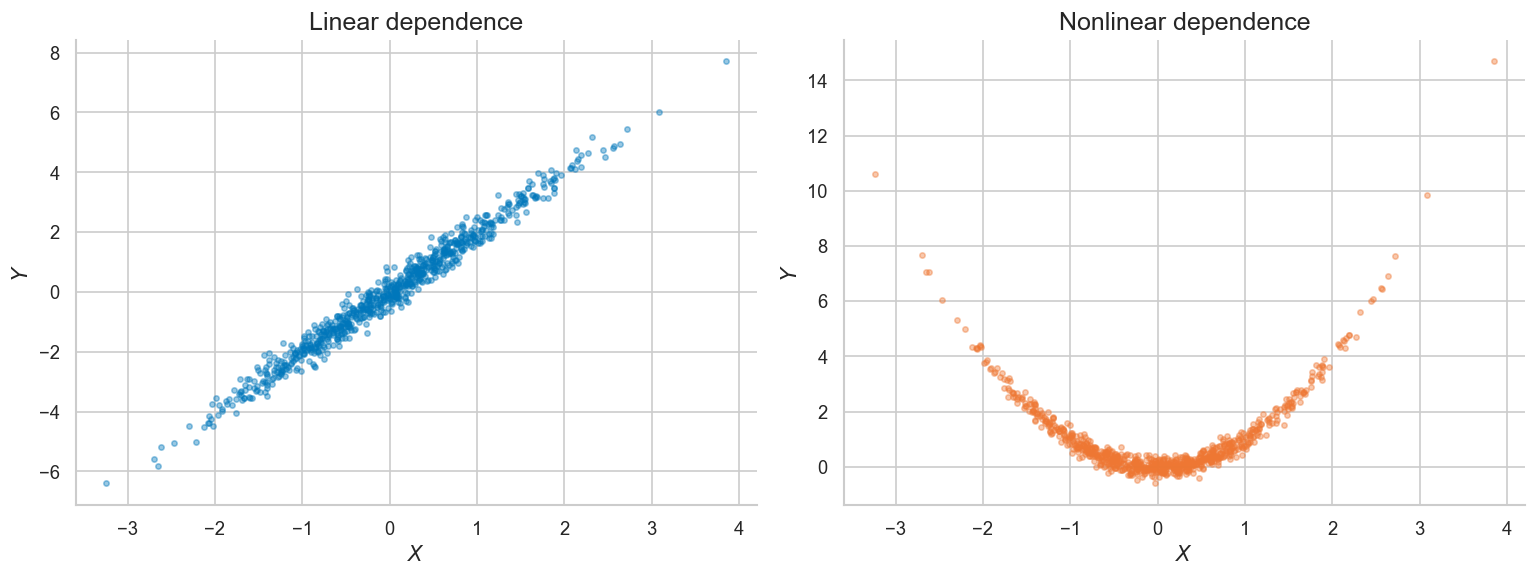

In [3]:
# === 1.1 Correlation can miss nonlinear dependence ===
np.random.seed(42)
N = 5000
X = np.random.randn(N)
Y_linear = 2 * X + 0.3 * np.random.randn(N)
Y_nonlinear = X**2 + 0.2 * np.random.randn(N)

corr_linear = np.corrcoef(X, Y_linear)[0, 1]
corr_nonlinear = np.corrcoef(X, Y_nonlinear)[0, 1]
mi_linear = histogram_mi(X, Y_linear, bins=30)
mi_nonlinear = histogram_mi(X, Y_nonlinear, bins=30)

print('=== Dependence vs correlation ===')
print(f'Linear pair:    corr = {corr_linear:.4f}, histogram-MI = {mi_linear:.4f}')
print(f'Nonlinear pair: corr = {corr_nonlinear:.4f}, histogram-MI = {mi_nonlinear:.4f}')
ok = abs(corr_nonlinear) < 0.1 and mi_nonlinear > 0.2
print(f"{'PASS' if ok else 'FAIL'} — nonlinear dependence survives even when correlation is small")

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(X[:800], Y_linear[:800], s=10, alpha=0.4, color=COLORS['primary'])
    axes[0].set_title('Linear dependence')
    axes[0].set_xlabel('$X$')
    axes[0].set_ylabel('$Y$')

    axes[1].scatter(X[:800], Y_nonlinear[:800], s=10, alpha=0.4, color=COLORS['secondary'])
    axes[1].set_title('Nonlinear dependence')
    axes[1].set_xlabel('$X$')
    axes[1].set_ylabel('$Y$')

    fig.tight_layout()
    plt.show()
    plt.close('all')

---

## 2. Discrete Mutual Information and Uncertainty Reduction

We start with an exact joint table so every identity can be checked by hand.

In [4]:
# === 2.1 Exact MI from a 2x2 joint table ===
P = np.array([[0.4, 0.1],
              [0.1, 0.4]])
px = P.sum(axis=1)
py = P.sum(axis=0)
Hx = entropy(px)
Hy = entropy(py)
Hxy = entropy(P.ravel())
mi = mutual_info_from_joint(P)
print('Joint table:')
print(P)
print(f'H(X)   = {Hx:.6f}')
print(f'H(Y)   = {Hy:.6f}')
print(f'H(X,Y) = {Hxy:.6f}')
print(f'I(X;Y) = {mi:.6f}')
check = Hx + Hy - Hxy
ok = np.allclose(mi, check)
print(f"{'PASS' if ok else 'FAIL'} — I(X;Y) = H(X)+H(Y)-H(X,Y)")

Joint table:
[[0.4 0.1]
 [0.1 0.4]]
H(X)   = 0.693147
H(Y)   = 0.693147
H(X,Y) = 1.193550
I(X;Y) = 0.192745
PASS — I(X;Y) = H(X)+H(Y)-H(X,Y)


---

## 3. Mutual Information as KL Divergence

The defining structural identity is

$$I(X;Y) = D_{\mathrm{KL}}(p_{XY} \| p_X p_Y).$$

Below we verify the equality on the same table.

In [5]:
# === 3.1 Verify MI = KL(joint || product of marginals) ===
product = np.outer(px, py)
with np.errstate(divide='ignore', invalid='ignore'):
    kl = np.sum(np.where(P > 0, P * np.log(P / product), 0.0))

print('Product of marginals:')
print(product)
print(f'MI from entropy identities: {mi:.6f}')
print(f'KL(P_xy || P_x P_y):      {kl:.6f}')
ok = np.allclose(mi, kl)
print(f"{'PASS' if ok else 'FAIL'} — mutual information is a KL divergence to independence")

Product of marginals:
[[0.25 0.25]
 [0.25 0.25]]
MI from entropy identities: 0.192745
KL(P_xy || P_x P_y):      0.192745
PASS — mutual information is a KL divergence to independence


---

## 4. Pointwise Mutual Information (PMI)

PMI is the local version of mutual information: it scores a *single pair* rather than averaging over all pairs.

In [6]:
# === 4.1 PMI for toy word co-occurrences ===
words_x = ['new', 'deep', 'rare']
words_y = ['york', 'learning', 'event']
P_words = np.array([[0.18, 0.01, 0.01],
                    [0.01, 0.15, 0.04],
                    [0.01, 0.03, 0.56]])
px_words = P_words.sum(axis=1)
py_words = P_words.sum(axis=0)
PMI = np.log(P_words / np.outer(px_words, py_words))

print('PMI matrix:')
for i, wx in enumerate(words_x):
    row = ', '.join(f'{words_y[j]}: {PMI[i, j]: .3f}' for j in range(len(words_y)))
    print(f"{wx:>5} -> {row}")

best = np.unravel_index(np.argmax(PMI), PMI.shape)
print(f'Highest PMI pair: ({words_x[best[0]]}, {words_y[best[1]]})')
ok = PMI[0, 0] > PMI[0, 1] and PMI[1, 1] > 0
print(f"{'PASS' if ok else 'FAIL'} — PMI highlights specific associations instead of raw frequency")

PMI matrix:
  new -> york:  1.504, learning: -1.335, event: -2.501
 deep -> york: -1.386, learning:  1.373, event: -1.115
 rare -> york: -2.485, learning: -1.335, event:  0.425
Highest PMI pair: (new, york)
PASS — PMI highlights specific associations instead of raw frequency


---

## 5. Conditional Mutual Information

Conditional MI tells us how much dependence remains after conditioning on a third variable. Two classic patterns are:

- a common cause, where conditioning can remove dependence
- a synergy/collider pattern, where conditioning can reveal dependence

In [7]:
# === 5.1 Conditioning can remove or reveal dependence ===
# Example A: common cause Z -> X, Z -> Y
Pxyz = np.zeros((2, 2, 2))
for z in [0, 1]:
    pz = 0.5
    px_given_z = np.array([0.9, 0.1]) if z == 0 else np.array([0.1, 0.9])
    py_given_z = np.array([0.8, 0.2]) if z == 0 else np.array([0.2, 0.8])
    for x in [0, 1]:
        for y in [0, 1]:
            Pxyz[x, y, z] = pz * px_given_z[x] * py_given_z[y]

Pxy = Pxyz.sum(axis=2)
mi_xy = mutual_info_from_joint(Pxy)
cmi_xyz = conditional_mi_from_joint_xyz(Pxyz)

# Example B: XOR synergy: X and Y independent, Z = X xor Y
Pxyz_xor = np.zeros((2, 2, 2))
for x in [0, 1]:
    for y in [0, 1]:
        z = x ^ y
        Pxyz_xor[x, y, z] += 0.25
mi_xy_xor = mutual_info_from_joint(Pxyz_xor.sum(axis=2))
cmi_xy_given_z_xor = conditional_mi_from_joint_xyz(np.transpose(Pxyz_xor, (0, 1, 2)))

print('Common-cause example:')
print(f'  I(X;Y)        = {mi_xy:.6f}')
print(f'  I(X;Y|Z)      = {cmi_xyz:.6f}')
print('XOR example:')
print(f'  I(X;Y)        = {mi_xy_xor:.6f}')
print(f'  I(X;Y|Z)      = {cmi_xy_given_z_xor:.6f}')
ok = mi_xy > cmi_xyz and np.isclose(mi_xy_xor, 0.0) and cmi_xy_given_z_xor > 0.6
print(f"{'PASS' if ok else 'FAIL'} — conditioning can either remove or reveal dependence")

Common-cause example:
  I(X;Y)        = 0.120090
  I(X;Y|Z)      = -0.000000
XOR example:
  I(X;Y)        = 0.000000
  I(X;Y|Z)      = 0.693147
PASS — conditioning can either remove or reveal dependence


---

## 6. Symmetry, Nonnegativity, and Bounds

Because MI is a KL divergence to the product of marginals, it inherits nonnegativity. We can also verify the standard upper bound

$$0 \le I(X;Y) \le \min\{H(X), H(Y)\}$$

numerically over random tables.

In [8]:
# === 6.1 Random verification of symmetry, positivity, and bounds ===
np.random.seed(7)
all_ok = True
for _ in range(200):
    A = np.random.rand(4, 5)
    P = A / A.sum()
    mi_val = mutual_info_from_joint(P)
    mi_transpose = mutual_info_from_joint(P.T)
    Hx = entropy(P.sum(axis=1))
    Hy = entropy(P.sum(axis=0))
    cond = (mi_val >= -1e-10) and np.allclose(mi_val, mi_transpose) and (mi_val <= min(Hx, Hy) + 1e-10)
    all_ok &= cond

print(f'Checked 200 random joint tables.')
print(f"{'PASS' if all_ok else 'FAIL'} — symmetry, nonnegativity, and bounds all hold numerically")

Checked 200 random joint tables.
PASS — symmetry, nonnegativity, and bounds all hold numerically


---

## 7. Chain Rule

The chain rule says

$$I(X,Z;Y) = I(X;Y) + I(Z;Y\mid X).$$

This is the information-theoretic version of decomposing what is already explained and what is added conditionally.

In [9]:
# === 7.1 Verify the chain rule on a synthetic joint distribution ===
# Build a small joint over X,Z,Y by sampling and tabulating
np.random.seed(11)
N = 200000
X = np.random.binomial(1, 0.5, size=N)
Z = np.random.binomial(1, 0.5, size=N)
Y = (X + Z + np.random.binomial(1, 0.2, size=N)) % 2

Pxyz = np.zeros((2, 2, 2), dtype=float)
for x, z, y in zip(X, Z, Y):
    Pxyz[x, z, y] += 1
Pxyz /= N

Pxzy = np.transpose(Pxyz, (0, 1, 2))
# I((X,Z);Y)
P_xz_y = Pxyz.reshape(4, 2)
mi_xz_y = mutual_info_from_joint(P_xz_y)
# I(X;Y)
P_xy = Pxyz.sum(axis=1)
mi_x_y = mutual_info_from_joint(P_xy)
# I(Z;Y|X)
P_zy_x = np.transpose(Pxyz, (1, 2, 0))
# Build P(z,y,x) with x as conditioner in last axis for helper pattern
Pzyx = P_zy_x
# helper expects shape (x,y,z), so relabel variables as (Z,Y,X)
mi_z_y_given_x = conditional_mi_from_joint_xyz(Pzyx)

lhs = mi_xz_y
rhs = mi_x_y + mi_z_y_given_x
print(f'I((X,Z);Y)      = {lhs:.6f}')
print(f'I(X;Y)+I(Z;Y|X) = {rhs:.6f}')
ok = np.allclose(lhs, rhs, atol=2e-3)
print(f"{'PASS' if ok else 'FAIL'} — chain rule verified numerically")

I((X,Z);Y)      = 0.194339
I(X;Y)+I(Z;Y|X) = 0.194339
PASS — chain rule verified numerically


---

## 8. Deterministic Functions and Invariance

A bijection should preserve MI, while a coarse deterministic map can only reduce it.

In [10]:
# === 8.1 Bijection preserves MI; coarse maps reduce it ===
P = np.array([[0.30, 0.05, 0.00],
              [0.10, 0.25, 0.05],
              [0.00, 0.05, 0.20]])
P /= P.sum()
mi_original = mutual_info_from_joint(P)

# Bijection: permute X states
P_perm = P[[2, 0, 1], :]
mi_perm = mutual_info_from_joint(P_perm)

# Coarse map: merge first two X states
P_coarse = np.vstack([P[:2, :].sum(axis=0), P[2:, :].sum(axis=0)])
mi_coarse = mutual_info_from_joint(P_coarse)

print(f'Original MI:   {mi_original:.6f}')
print(f'Permuted MI:   {mi_perm:.6f}')
print(f'Coarsened MI:  {mi_coarse:.6f}')
ok = np.allclose(mi_original, mi_perm) and mi_coarse <= mi_original + 1e-10
print(f"{'PASS' if ok else 'FAIL'} — bijections preserve MI; coarse deterministic maps do not increase it")

Original MI:   0.451784
Permuted MI:   0.451784
Coarsened MI:  0.293694
PASS — bijections preserve MI; coarse deterministic maps do not increase it


---

## 9. Data Processing Inequality

For a Markov chain $X 	o T 	o Y$, processing through $T$ cannot increase information about $X$.

In [11]:
# === 9.1 Verify the data processing inequality on a binary Markov chain ===
np.random.seed(3)
N = 300000
X = np.random.binomial(1, 0.5, size=N)
noise1 = np.random.binomial(1, 0.15, size=N)
noise2 = np.random.binomial(1, 0.20, size=N)
T = X ^ noise1
Y = T ^ noise2

P_xt = np.zeros((2, 2))
P_xy = np.zeros((2, 2))
for x, t, y in zip(X, T, Y):
    P_xt[x, t] += 1
    P_xy[x, y] += 1
P_xt /= N
P_xy /= N
I_xt = mutual_info_from_joint(P_xt)
I_xy = mutual_info_from_joint(P_xy)
print(f'I(X;T) = {I_xt:.6f}')
print(f'I(X;Y) = {I_xy:.6f}')
ok = I_xy <= I_xt + 1e-10
print(f"{'PASS' if ok else 'FAIL'} — information decreases under further noisy processing")

I(X;T) = 0.271364
I(X;Y) = 0.091791
PASS — information decreases under further noisy processing


---

## 10. Synergy and Total Correlation

Pairwise MI can miss higher-order structure. XOR is the standard example.

In [12]:
# === 10.1 XOR synergy and total correlation ===
Pxyz = np.zeros((2, 2, 2))
for x in [0, 1]:
    for z in [0, 1]:
        y = x ^ z
        Pxyz[x, z, y] += 0.25

# Pairwise MI between X and Y
P_xy = Pxyz.sum(axis=1)
P_zy = Pxyz.sum(axis=0)
I_x_y = mutual_info_from_joint(P_xy)
I_z_y = mutual_info_from_joint(P_zy)
# Joint information I((X,Z);Y)
I_xz_y = mutual_info_from_joint(Pxyz.reshape(4, 2))
# Total correlation of the triple
TC = total_correlation_3(np.transpose(Pxyz, (0, 1, 2)))

print(f'I(X;Y)         = {I_x_y:.6f}')
print(f'I(Z;Y)         = {I_z_y:.6f}')
print(f'I((X,Z);Y)     = {I_xz_y:.6f}')
print(f'Total corr(X,Z,Y) = {TC:.6f}')
ok = np.isclose(I_x_y, 0.0) and np.isclose(I_z_y, 0.0) and np.isclose(I_xz_y, np.log(2), atol=1e-10)
print(f"{'PASS' if ok else 'FAIL'} — XOR has synergy: no pairwise information, but full joint information")

I(X;Y)         = 0.000000
I(Z;Y)         = 0.000000
I((X,Z);Y)     = 0.693147
Total corr(X,Z,Y) = 0.693147
PASS — XOR has synergy: no pairwise information, but full joint information


---

## 11. Channel Mutual Information and Capacity

A channel is a conditional law $p(y|x)$. The binary symmetric channel is the cleanest exact example.

BSC mutual information at selected noise levels:
  eps=0.00 -> I(X;Y)=0.693147 nats
  eps=0.10 -> I(X;Y)=0.368064 nats
  eps=0.25 -> I(X;Y)=0.130812 nats
  eps=0.49 -> I(X;Y)=0.000200 nats


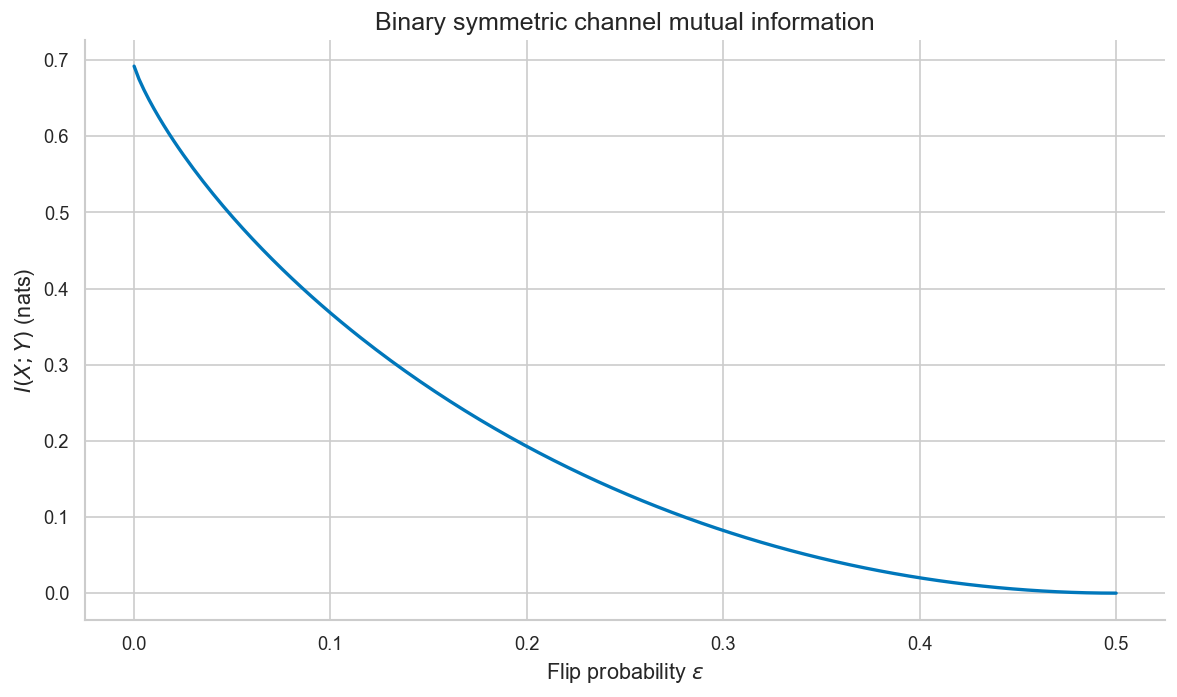

In [13]:
# === 11.1 Binary symmetric channel: I(X;Y) = 1 - h2(eps) for uniform input ===
eps = np.linspace(1e-4, 0.4999, 200)
mi_bsc = np.log(2) - binary_entropy(eps)  # nats for uniform Bern(1/2) input

print('BSC mutual information at selected noise levels:')
for e in [0.0, 0.1, 0.25, 0.49]:
    e_clip = min(max(e, 1e-8), 1 - 1e-8)
    print(f'  eps={e:>4.2f} -> I(X;Y)={np.log(2) - binary_entropy(e_clip):.6f} nats')

if HAS_MPL:
    fig, ax = plt.subplots()
    ax.plot(eps, mi_bsc, color=COLORS['primary'])
    ax.set_title('Binary symmetric channel mutual information')
    ax.set_xlabel('Flip probability $\\epsilon$')
    ax.set_ylabel('$I(X;Y)$ (nats)')
    fig.tight_layout()
    plt.show()
    plt.close('all')

---

## 12. Gaussian Mutual Information

For jointly Gaussian variables with correlation $
ho$, the mutual information has a closed form:

$$I(X;Y) = -	frac12 \log(1-
ho^2).$$

In [14]:
# === 12.1 Closed-form MI for correlated Gaussians ===
rhos = np.linspace(-0.95, 0.95, 200)
mi_closed = -0.5 * np.log(1 - rhos**2)

rho = 0.7
cov = np.array([[1.0, rho], [rho, 1.0]])
samples = np.random.multivariate_normal([0.0, 0.0], cov, size=20000)
mi_hist = histogram_mi(samples[:, 0], samples[:, 1], bins=35)
mi_true = -0.5 * np.log(1 - rho**2)

print(f'Closed-form MI at rho={rho:.2f}: {mi_true:.6f}')
print(f'Histogram estimate:           {mi_hist:.6f}')
print(f'Difference:                   {abs(mi_hist - mi_true):.6f}')

if HAS_MPL:
    fig, ax = plt.subplots()
    ax.plot(rhos, mi_closed, color=COLORS['secondary'])
    ax.set_title('Mutual information for correlated Gaussians')
    ax.set_xlabel('Correlation $\\rho$')
    ax.set_ylabel('$I(X;Y)$ (nats)')
    fig.tight_layout()
    plt.show()
    plt.close('all')

SyntaxError: unterminated string literal (detected at line 19) (1575914463.py, line 19)

---

## 13. Fano's Inequality and Prediction Limits

Fano's inequality says low information about the label implies nontrivial classification error. We can see the trend numerically in a small noisy decoding problem.

In [ ]:
# === 13.1 Noisy 4-class decoding and a Fano-style bound ===
M = 4
labels = np.arange(M)
P_y = np.ones(M) / M
p_correct = 0.7
P_x_given_y = np.full((M, M), (1 - p_correct) / (M - 1))
np.fill_diagonal(P_x_given_y, p_correct)
P_yx = (P_y[:, None] * P_x_given_y)
I_y_x = mutual_info_from_joint(P_yx)
H_y = np.log(M)
H_y_given_x = H_y - I_y_x
P_e = 1 - p_correct
rhs = binary_entropy(P_e) + P_e * np.log(M - 1)

print(f'H(Y)          = {H_y:.6f}')
print(f'I(Y;X)        = {I_y_x:.6f}')
print(f'H(Y|X)        = {H_y_given_x:.6f}')
print(f'Fano RHS      = {rhs:.6f}')
ok = H_y_given_x <= rhs + 1e-10
print(f"{'PASS' if ok else 'FAIL'} — conditional entropy respects the Fano upper bound")

---

## 14. Why Estimation Is Hard

Even for simple continuous variables, a naive histogram estimator can be biased. The estimator depends on sample size and bin count.

In [ ]:
# === 14.1 Histogram-estimator sensitivity ===
rho = 0.6
cov = np.array([[1.0, rho], [rho, 1.0]])
mi_true = -0.5 * np.log(1 - rho**2)
sample_sizes = [300, 1000, 5000]
all_estimates = {}
for n in sample_sizes:
    samp = np.random.multivariate_normal([0.0, 0.0], cov, size=n)
    ests = []
    for bins in [8, 12, 20, 35]:
        ests.append(histogram_mi(samp[:, 0], samp[:, 1], bins=bins))
    all_estimates[n] = ests

print(f'True MI = {mi_true:.6f}')
for n, ests in all_estimates.items():
    print(f'n={n:>5}: ' + ', '.join(f'{v:.4f}' for v in ests))
print('Takeaway: same data-generating process, different estimator settings -> different MI values.')

---

## 15. Classical Estimators vs Independence

Even a crude estimator should at least separate strongly dependent pairs from independent ones.

In [ ]:
# === 15.1 Independent vs dependent samples under the same estimator ===
N = 4000
x_dep = np.random.randn(N)
y_dep = x_dep + 0.5 * np.random.randn(N)

x_ind = np.random.randn(N)
y_ind = np.random.randn(N)

mi_dep = histogram_mi(x_dep, y_dep, bins=25)
mi_ind = histogram_mi(x_ind, y_ind, bins=25)

print(f'Dependent pair estimate:   {mi_dep:.6f}')
print(f'Independent pair estimate: {mi_ind:.6f}')
ok = mi_dep > mi_ind + 0.2
print(f"{'PASS' if ok else 'FAIL'} — estimator distinguishes clear dependence from independence in an easy case")

---

## 16. Variational Lower Bounds and InfoNCE

Contrastive learning rarely computes MI directly. Instead it uses lower bounds. The most widely used is InfoNCE.

In [ ]:
# === 16.1 InfoNCE lower bound on correlated Gaussian views ===
np.random.seed(123)
N = 3000
rho = 0.8
z1 = np.random.randn(N, 1)
z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.randn(N, 1)
true_mi = -0.5 * np.log(1 - rho**2)

def infonce_bound(K, temperature=0.2):
    idx = np.random.choice(N, size=400, replace=False)
    x = z1[idx]
    y_pos = z2[idx]
    pos = (x * y_pos)[:, 0] / temperature
    losses = []
    for i, score in enumerate(pos):
        neg_idx = np.random.choice(N, size=K - 1, replace=False)
        neg = (x[i] * z2[neg_idx]).reshape(-1) / temperature
        all_scores = np.concatenate([[score], neg])
        losses.append(-score + np.log(np.sum(np.exp(all_scores))))
    return np.log(K) - np.mean(losses)

Ks = [4, 8, 16, 32, 64]
bounds = np.array([infonce_bound(K) for K in Ks])
print(f'True Gaussian MI: {true_mi:.6f}')
for K, b in zip(Ks, bounds):
    print(f'K={K:>2} negatives -> InfoNCE lower bound ~ {b:.6f}')
ok = np.all(bounds <= true_mi + 0.5) and bounds[-1] >= bounds[0] - 1e-6
print(f"{'PASS' if ok else 'FAIL'} — InfoNCE behaves like a lower-bound-style objective and usually improves with more negatives")

---

## 17. A Donsker-Varadhan / MINE-Style View

MINE uses a neural critic to optimize a variational KL representation. To keep the example transparent, we use a simple bilinear critic $T_a(x,y)=a x y$ and optimize over $a$ on a grid.

In [ ]:
# === 17.1 DV-style lower bound with a simple critic ===
np.random.seed(10)
rho = 0.6
cov = np.array([[1.0, rho], [rho, 1.0]])
xy = np.random.multivariate_normal([0.0, 0.0], cov, size=12000)
xy_prod = np.column_stack([xy[:, 0], np.random.permutation(xy[:, 1])])

true_mi = -0.5 * np.log(1 - rho**2)
a_grid = np.linspace(-1.0, 1.0, 301)
dv_vals = []
for a in a_grid:
    T_joint = a * xy[:, 0] * xy[:, 1]
    T_prod = a * xy_prod[:, 0] * xy_prod[:, 1]
    dv = np.mean(T_joint) - np.log(np.mean(np.exp(T_prod)))
    dv_vals.append(dv)
dv_vals = np.array(dv_vals)
a_star = a_grid[np.argmax(dv_vals)]
dv_best = dv_vals.max()

print(f'True MI:              {true_mi:.6f}')
print(f'Best DV lower bound:  {dv_best:.6f} at a={a_star:.3f}')
ok = dv_best <= true_mi + 1e-8
print(f"{'PASS' if ok else 'FAIL'} — the variational objective acts as a lower bound here")

if HAS_MPL:
    fig, ax = plt.subplots()
    ax.plot(a_grid, dv_vals, color=COLORS['highlight'])
    ax.axhline(true_mi, color=COLORS['neutral'], linestyle='--', label='True MI')
    ax.set_title('DV-style lower bound with a simple critic')
    ax.set_xlabel('critic parameter $a$')
    ax.set_ylabel('lower bound value')
    ax.legend()
    fig.tight_layout()
    plt.show()
    plt.close('all')

---

## 18. Information Bottleneck as Compression vs Relevance

The information bottleneck objective asks for a representation $T$ that compresses $X$ but preserves what matters about $Y$. A tiny discrete example makes the trade-off concrete.

In [ ]:
# === 18.1 Toy discrete information bottleneck table ===
# X = (useful_bit, nuisance_bit) with 4 equally likely states
states = [(0,0), (0,1), (1,0), (1,1)]
P_x = np.ones(4) / 4
Y = np.array([s[0] for s in states])  # target depends only on first bit

# Candidate representations
T_identity = np.arange(4)            # keeps everything
T_useful = np.array([s[0] for s in states])
T_nuisance = np.array([s[1] for s in states])


def joint_from_maps(T):
    n_t = int(T.max()) + 1
    P_xt = np.zeros((4, n_t))
    P_ty = np.zeros((n_t, 2))
    for i in range(4):
        P_xt[i, T[i]] += P_x[i]
        P_ty[T[i], Y[i]] += P_x[i]
    return P_xt, P_ty

for name, T in [('identity', T_identity), ('useful bit', T_useful), ('nuisance bit', T_nuisance)]:
    P_xt, P_ty = joint_from_maps(T)
    I_xt = mutual_info_from_joint(P_xt)
    I_ty = mutual_info_from_joint(P_ty)
    print(f"{name:>11}: I(X;T)={I_xt:.6f}, I(T;Y)={I_ty:.6f}")

print('Takeaway: the useful-bit representation keeps task information while compressing away nuisance detail.')

---

## 19. Information Gain and Feature Selection

Decision trees choose features that reduce label entropy the most. In other words, they pick the feature with largest $I(X_j;Y)$.

In [ ]:
# === 19.1 MI-based feature ranking ===
np.random.seed(21)
N = 4000
x_good = np.random.binomial(1, 0.5, size=N)
x_noise = np.random.binomial(1, 0.5, size=N)
y = x_good ^ np.random.binomial(1, 0.1, size=N)  # mostly determined by x_good

P_good = np.zeros((2, 2))
P_noise = np.zeros((2, 2))
for a, b, c in zip(x_good, x_noise, y):
    P_good[a, c] += 1
    P_noise[b, c] += 1
P_good /= N
P_noise /= N

I_good = mutual_info_from_joint(P_good)
I_noise = mutual_info_from_joint(P_noise)
print(f'I(x_good; y)  = {I_good:.6f}')
print(f'I(x_noise; y) = {I_noise:.6f}')
ok = I_good > I_noise + 0.1
print(f"{'PASS' if ok else 'FAIL'} — MI ranks the informative feature above the nuisance feature")

---

## 20. Contrastive Predictive Coding and Self-Supervised Learning

Contrastive objectives can be understood as trying to preserve the information shared between two views of the same underlying example.

In [ ]:
# === 20.1 Positive-pair similarity vs negative-pair similarity ===
np.random.seed(0)
N = 64
D = 16
base = np.random.randn(N, D)
view1 = base + 0.2 * np.random.randn(N, D)
view2 = base + 0.2 * np.random.randn(N, D)
view1 = view1 / np.linalg.norm(view1, axis=1, keepdims=True)
view2 = view2 / np.linalg.norm(view2, axis=1, keepdims=True)
S = view1 @ view2.T
positive = np.mean(np.diag(S))
negative = np.mean(S[~np.eye(N, dtype=bool)])
retrieval = np.mean(np.argmax(S, axis=1) == np.arange(N))

print(f'Average positive similarity: {positive:.4f}')
print(f'Average negative similarity: {negative:.4f}')
print(f'Top-1 retrieval accuracy:    {retrieval:.2%}')
ok = positive > negative and retrieval > 0.5
print(f"{'PASS' if ok else 'FAIL'} — matched views retain more shared information than mismatched views")

---

## 21. CLIP-Style Multimodal Alignment

In CLIP-like models, the aim is to build embeddings where matched image-text pairs carry shared semantic information and mismatched pairs do not.

In [ ]:
# === 21.1 Toy image-text alignment matrix ===
np.random.seed(9)
N = 32
D = 20
semantic = np.random.randn(N, D)
image_embed = semantic + 0.3 * np.random.randn(N, D)
text_embed = semantic + 0.3 * np.random.randn(N, D)
image_embed /= np.linalg.norm(image_embed, axis=1, keepdims=True)
text_embed /= np.linalg.norm(text_embed, axis=1, keepdims=True)
S = image_embed @ text_embed.T
img_to_txt = np.mean(np.argmax(S, axis=1) == np.arange(N))
txt_to_img = np.mean(np.argmax(S, axis=0) == np.arange(N))

print(f'Image->text retrieval: {img_to_txt:.2%}')
print(f'Text->image retrieval: {txt_to_img:.2%}')

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(S, cmap='viridis', aspect='auto')
    fig.colorbar(im, ax=ax, label='cosine similarity')
    ax.set_title('Toy CLIP-style similarity matrix')
    ax.set_xlabel('text index')
    ax.set_ylabel('image index')
    fig.tight_layout()
    plt.show()
    plt.close('all')

---

## 22. Active Learning and Bayesian Experimental Design

A BALD-style score measures how informative a candidate query would be about uncertain parameters.

In [ ]:
# === 22.1 Toy BALD calculation ===
# Theta in {0,1} with equal prior. Each candidate x induces a Bernoulli label model.
candidates = {
    'uninformative': (0.50, 0.50),
    'moderate':      (0.75, 0.25),
    'very informative': (0.95, 0.05),
}

def bald_score(p_y1_given_theta0, p_y1_given_theta1):
    p_theta = np.array([0.5, 0.5])
    p_y1 = np.dot(p_theta, [p_y1_given_theta0, p_y1_given_theta1])
    H_y = binary_entropy(p_y1)
    H_y_given_theta = 0.5 * binary_entropy(p_y1_given_theta0) + 0.5 * binary_entropy(p_y1_given_theta1)
    return H_y - H_y_given_theta

for name, (p0, p1) in candidates.items():
    score = bald_score(p0, p1)
    print(f"{name:>16}: I(Y;Theta|x) = {score:.6f} nats")

print('Takeaway: the best query is the one whose label would most reduce uncertainty about the model state.')

---

## 23. Summary Checks

We finish by checking the chapter's main identities one more time on a fresh random table.

In [ ]:
# === 23.1 Final summary verification ===
np.random.seed(1234)
A = np.random.rand(3, 4)
P = A / A.sum()
px = P.sum(axis=1)
py = P.sum(axis=0)
mi = mutual_info_from_joint(P)
Hx = entropy(px)
Hy = entropy(py)
Hxy = entropy(P.ravel())
kl = np.sum(np.where(P > 0, P * np.log(P / np.outer(px, py)), 0.0))

checks = {
    'MI = H(X)+H(Y)-H(X,Y)': np.allclose(mi, Hx + Hy - Hxy),
    'MI = KL(joint || product)': np.allclose(mi, kl),
    'MI >= 0': mi >= -1e-10,
    'MI <= min(HX, HY)': mi <= min(Hx, Hy) + 1e-10,
}
for name, cond in checks.items():
    print(f"{'PASS' if cond else 'FAIL'} — {name}")

print(f'\\nExample MI value: {mi:.6f} nats')
print('Notebook complete. Next: use exercises.ipynb to practice the identities and applications.')

---

Mutual information is one of the few quantities that is equally at home in communication theory, statistical dependence, representation learning, and active data acquisition. The formulas are compact, but the design consequences for AI are large.